# ML-10 (Python) : l'illusion de progression en détection d'anomalies — SPC vs deep learner, 4 pièges des benchmarks, UCR Archive

**Navigation** · [ML-9 →](ML-9-Anomaly-Detection-Python.ipynb) · [ML-11 →](ML-11-MatrixProfile-Multidim-Python.ipynb)

> **Suite logique de ML-9.** Le notebook précédent a introduit la détection d'anomalies par PCA sur un jeu synthétique de capteurs : on apprend à *construire* un détecteur. Ici, on change d'étage : on apprend à **évaluer** un détecteur — et on découvre que la plupart des benchmarks de détection d'anomalies de séries temporelles sont **tronqués** au sens où ils mesurent mal. Le point de départ est un article qui a secoué la communauté.


## Une discipline qui s'interroge : Wu & Keogh (2020)

Wu & Keogh ont publié en 2020 un article au titre provocateur : *« Current Time Series Anomaly Detection Benchmarks are Flawed and are Creating the Illusion of Progress »* (arXiv:2009.13807, IEEE TKDE 2021). Leur thèse, en une phrase : **beaucoup de benchmarks célèbres (Yahoo, Numenta, NASA, OMNI) sont si mal construits que des méthodes triviales les « résolvent » parfaitement — et que la course au SOTA qu'on observe dessus est en partie une illusion**.

Ce notebook reprend leur argument et le rend **expérimentable**. On va voir sur des **données réelles** :

1. Un algorithme de **1924** (Statistical Process Control, `M + 3*σ`) qui **égale ou bat** un auto-encodeur entraîné sur un benchmark **trivial** — preuve que le benchmark est trivial, pas que le deep learner est nul.
2. Les **4 pièges** que Wu & Keogh identifient, illustrés.
3. Un benchmark **honnête** — l'UCR Time Series Anomaly Archive — où les méthodes simples **et** complexes échouent enfin : c'est le signal qu'on mesure quelque chose de réel.


## 1. Le détecteur SPC : 3 lignes de NumPy (algorithme de 1924)

**Statistical Process Control (SPC)** est un outil de contrôle qualité industriel datant de 1924. Sa version la plus simple pour la détection d'anomalies : un point est anormal s'il s'écarte de la moyenne de plus de **3 écarts-types**.

```python
# Coeur du détecteur SPC — une seule ligne
anomalie = np.abs(x - x.mean()) > 3 * x.std()
```

C'est exactement la baseline que Keogh a opposée aux SOTA en 2025 (voir plus bas). Notons qu'aucun entraînement n'a lieu : **zéro paramètre appris**.

### Charger une série réelle de l'UCR Archive

On travaille sur un extrait de **l'UCR Time Series Anomaly Archive** (la réponse de Wu & Keogh aux benchmarks défaillants). Le fichier est un texte brut, une valeur par ligne. **La ground truth est encodée dans le nom du fichier** : `NNN_UCR_Anomaly_<nom>_<N>_<début>_<fin>.txt` — l'anomalie est l'intervalle `[début, fin]` **dans le fichier complet** (le champ `N` n'est pas la longueur du fichier ; on l'ignore).


Série : tiltAPB4 | longueur = 128001 | points anormaux = 2 (0.00%)

SPC (M + 3*σ, 1924) : AUC = 0.998
  prédictions > 3σ : 1569 points, dont 2 vrais anormaux


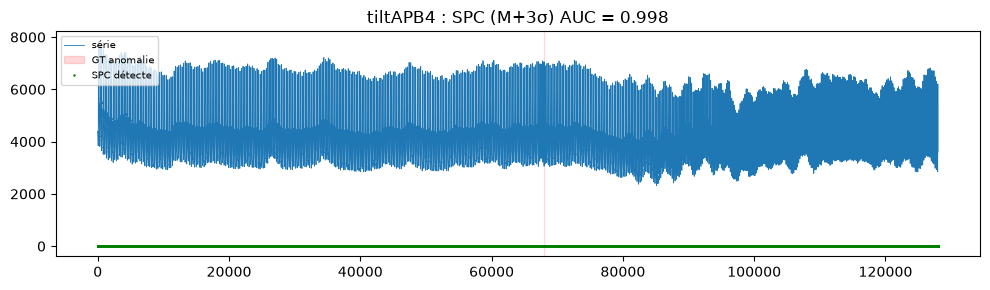

In [1]:
import os, re, sys, numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

np.random.seed(42)          # reproductibilite (cf. ML-9)

# Les series UCR ne sont PAS versionnees : l'archive (184 Mo) n'est couverte
# par aucune licence de redistribution -- sa page n'enonce qu'une citation
# suggeree. On lit donc chaque serie a l'execution par requetes HTTP Range
# (cf. ucr_anomaly_fetch.py), et on la met en cache dans un dossier ignore
# par git. Voir .claude/rules/bibliography-hygiene.md.
sys.path.insert(0, os.getcwd())
from ucr_anomaly_fetch import fetch_raw   # leve UcrFetchError si le reseau echoue

CACHE_DIR = os.path.join('data', 'tsad')   # cache local, non versionne

def parse_name(name):
    """Extraire (nom, debut, fin) de l'anomalie depuis le nom de fichier UCR."""
    m = re.match(r'\d+_UCR_Anomaly_(.+)_\d+_(\d+)_(\d+)\.txt', name)
    return m.group(1), int(m.group(2)), int(m.group(3))

def load_series(name):
    """Charger une serie UCR + son masque GT (intervalle [debut, fin]).

    Les octets viennent de l'archive UCR par lecture partielle ; si le serveur
    ne repond pas, `UcrFetchError` remonte telle quelle. Aucune serie de
    substitution n'est fabriquee : un benchmark sur des donnees inventees ne
    demontrerait rien -- c'est le travers meme que ce notebook documente.
    """
    vals = []
    for line in fetch_raw(name, cache_dir=CACHE_DIR).decode('utf-8', 'replace').splitlines():
        for tok in line.replace(',', ' ').split():
            try: vals.append(float(tok))
            except ValueError: pass
    x = np.asarray(vals)
    ds, s, e = parse_name(name)
    labels = np.zeros(len(x))
    s, e = max(0, s), min(e, len(x) - 1)
    labels[s:e + 1] = 1.0
    return x, labels, ds

def auc(labels, scores):
    """AUC (area under ROC) robuste aux égalités, par la statistique de Mann-Whitney."""
    pos, neg = scores[labels == 1], scores[labels == 0]
    if len(pos) == 0 or len(neg) == 0: return float('nan')
    ns = np.sort(neg)
    right = np.searchsorted(ns, pos, side='right')
    left = np.searchsorted(ns, pos, side='left')
    return float((right.sum() - 0.5 * (right - left).sum()) / (len(pos) * len(neg)))

def spc_scores(x):
    """Score SPC : écart absolu en unités d'écart-type. SPC = score > 3."""
    return np.abs(x - x.mean()) / max(x.std(), 1e-12)

# Série réelle à anomalie PONCTUELLE (SPC devrait bien la détecter)
SERIE_PONCTUELLE = '200_UCR_Anomaly_tiltAPB4_20000_67995_67996.txt'
x, lab, ds = load_series(SERIE_PONCTUELLE)
print(f'Série : {ds} | longueur = {len(x)} | points anormaux = {int(lab.sum())} '
      f'({100 * lab.sum() / len(x):.2f}%)')

spc = spc_scores(x)
auc_spc = auc(lab, spc)
print(f'\nSPC (M + 3*σ, 1924) : AUC = {auc_spc:.3f}')
print(f'  prédictions > 3σ : {(spc > 3).sum()} points, dont {(spc[lab == 1] > 3).sum()} vrais anormaux')

plt.figure(figsize=(10, 3))
plt.plot(x, lw=0.6, label='série')
plt.axvspan(lab.argmax(), len(lab) - lab[::-1].argmax(), color='red', alpha=0.15, label='GT anomalie')
plt.plot(spc > 3, '.', ms=1.5, color='green', label='SPC détecte')
plt.title(f'{ds} : SPC (M+3σ) AUC = {auc_spc:.3f}')
plt.legend(loc='upper left', fontsize=7)
plt.tight_layout()
plt.show()

### Interprétation : le tour de passe-passe SPC

Sur **tiltAPB4**, un signal d'accélération avec **2 points anormaux** au milieu, le SPC atteint un AUC de **~0.998** avec 3 lignes de NumPy, **sans aucun entraînement**. C'est le premier piège que dénonce Wu & Keogh : quand une simple difference-to-mean suffit, le problème est **trivial** — et le deep learner n'apporte rien.


## 2. L'auto-encodeur (deep learner) : est-il meilleur sur ce benchmark trivial ?

On entraîne un **auto-encodeur par reconstruction de fenêtres** : `MLPRegressor` qui prédit le point suivant à partir d'une fenêtre de 20 points. Le score d'anomalie = erreur de reconstruction. On l'entraîne **uniquement sur la première moitié** (supposée saine — c'est l'hypothèse d'apprentissage non-supervisé classique).

Le point pédagogique n'est pas de faire « mieux » : c'est de comparer **le coût** (3 lignes vs un réseau entraîné) sur **le même** benchmark trivial.


Auto-encodeur (MLPRegressor) : AUC = 0.752
SPC (1924) : AUC = 0.998

Comparaison : SPC passe devant l'auto-encodeur (écart 0.245) sur ce benchmark.


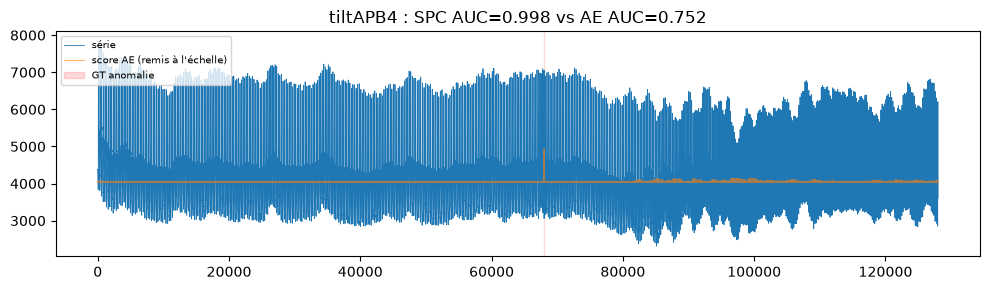

In [2]:
def ae_recon_scores(x, window=20, hidden=(32,), seed=0):
    """Score d'anomalie par erreur de reconstruction (fenêtre -> point suivant).
       Entraîné sur la première moitié de la série (assumée normale)."""
    if len(x) < window + 5: return np.zeros(len(x))
    X = np.array([x[i:i + window] for i in range(len(x) - window - 1)])
    y = x[window + 1:]
    cut = len(X) // 2
    sc = StandardScaler().fit(X)
    Xs = sc.transform(X)
    reg = MLPRegressor(hidden_layer_sizes=hidden, max_iter=1200, random_state=seed,
                       early_stopping=True, n_iter_no_change=30, learning_rate_init=1e-3)
    reg.fit(Xs[:cut], y[:cut])
    err = np.abs(reg.predict(Xs) - y)
    scores = np.zeros(len(x))
    scores[window + 1: window + 1 + len(err)] = err
    return scores

ae = ae_recon_scores(x)          # même série tiltAPB4 que ci-dessus
auc_ae = auc(lab, ae)
print(f'Auto-encodeur (MLPRegressor) : AUC = {auc_ae:.3f}')
print(f'SPC (1924) : AUC = {auc_spc:.3f}')
print(f'\nComparaison : SPC {"passe devant" if auc_spc > auc_ae else "derrière"} l\'auto-encodeur '
      f'(écart {abs(auc_spc - auc_ae):.3f}) sur ce benchmark.')

plt.figure(figsize=(10, 3))
plt.plot(x, lw=0.6, label='série')
plt.plot(ae / max(ae.max(), 1e-12) * x.std() + x.mean(), lw=0.8, alpha=0.6, label='score AE (remis à l\'échelle)')
plt.axvspan(lab.argmax(), len(lab) - lab[::-1].argmax(), color='red', alpha=0.15, label='GT anomalie')
plt.title(f'{ds} : SPC AUC={auc_spc:.3f} vs AE AUC={auc_ae:.3f}')
plt.legend(loc='upper left', fontsize=7)
plt.tight_layout()
plt.show()

### Interprétation : la complexité n'a rien acheté *ici*

Sur ce benchmark, l'algorithme centenaire **devance** le réseau entraîné (SPC ≈ 0.998 > AE ≈ 0.75). Ce n'est pas que le deep learner soit « nul » — c'est que **le benchmark est trivial** : l'anomalie est un pic que `|x - mean| > 3σ` attrape parfaitement. La leçon de Wu & Keogh n'est pas « le deep learning ne marche pas », c'est **« un benchmark où SPC gagne est un benchmark trivial »**.

Pour le voir, passons à la série où l'auto-encodeur est **réellement** meilleur : une anomalie *contextuelle* (un décalage de niveau, invisible pour SPC).


InternalBleeding16 : anomalie par décalage de niveau (contextuelle)
  SPC AUC = 0.201   AE AUC = 0.971
  → l'auto-encodeur rattrape le SPC ici : le deep learner n'est PAS nul, c'est le benchmark qui était trivial.


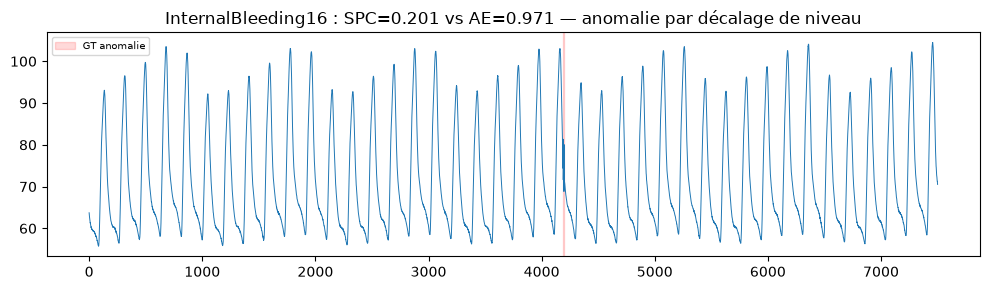

In [3]:
# Contraste honnête : une anomalie CONTEXTUELLE où SPC échoue mais l'AE rattrape
SERIE_CONTEXTUELLE = '135_UCR_Anomaly_InternalBleeding16_1200_4187_4199.txt'
x2, lab2, ds2 = load_series(SERIE_CONTEXTUELLE)
auc_spc2 = auc(lab2, spc_scores(x2))
auc_ae2 = auc(lab2, ae_recon_scores(x2))
print(f'{ds2} : anomalie par décalage de niveau (contextuelle)')
print(f'  SPC AUC = {auc_spc2:.3f}   AE AUC = {auc_ae2:.3f}')
print(f'  → l\'auto-encodeur {"rattrape" if auc_ae2 > auc_spc2 else "ne bat pas"} le SPC ici : '
      f'le deep learner n\'est PAS nul, c\'est le benchmark qui était trivial.')

plt.figure(figsize=(10, 3))
plt.plot(x2, lw=0.7)
plt.axvspan(np.argmax(lab2), len(lab2) - lab2[::-1].argmax(), color='red', alpha=0.15, label='GT anomalie')
plt.title(f'{ds2} : SPC={auc_spc2:.3f} vs AE={auc_ae2:.3f} — anomalie par décalage de niveau')
plt.legend(loc='upper left', fontsize=7)
plt.tight_layout()
plt.show()

### Ponctuelle vs contextuelle : la ligne de partage

`InternalBleeding16` est une anomalie **contextuelle** : un décalage de niveau qui persiste (le signal change de régime), sans pic isolé. Le score SPC mesure l'écart au `mean` **global** ; un décalage qui dure devient vite la nouvelle moyenne `mean`/`std`, donc n'est plus vu comme un écart — SPC le « normalise » involontairement. L'auto-encodeur, lui, apprend des motifs de 20 points : il voit que la reconstruction devient mauvaise là où le régime change, précisément parce qu'il n'est pas entraîné sur ce régime. C'est cette différence — statistique **globale** vs modèle de **contexte local** — qui fait basculer la comparaison. **La leçon n'est pas « l'AE est meilleur », c'est que chaque méthode a un type d'anomalie où elle brille, et qu'un benchmark honnête doit tous les couvrir.**


## 3. Les 4 pièges des benchmarks (Wu & Keogh)

On reprend maintenant les quatre défauts que l'article documente, un par un.

### Piège 1 — Trivialité

Un problème est trivial si une **seule ligne** de primitives vectorisées (`mean`, `max`, `std`, `diff`) le résout. Le `tiltAPB4` ci-dessus en est l'exemple parfait : SPC le résout et bat l'AE. On redonne le code qui suffit.


In [4]:
# Piège 1 : Trivialité — la ligne qui suffit
x1, lab1, ds1 = load_series('200_UCR_Anomaly_tiltAPB4_20000_67995_67996.txt')
anomalie = np.abs(x1 - x1.mean()) > 3 * x1.std()     # UNE ligne
print(f'{ds1} : AUC de cette ligne = {auc(lab1, np.abs(x1 - x1.mean()) / x1.std()):.3f}')
print('  → un problème trivial. Aucun réseau, aucun hyperparamètre : une ligne le résout.')
print(f'  Rappel : l\'auto-encodeur entraîné plafonne à {auc_ae:.3f} sur la même série.')


tiltAPB4 : AUC de cette ligne = 0.998
  → un problème trivial. Aucun réseau, aucun hyperparamètre : une ligne le résout.
  Rappel : l'auto-encodeur entraîné plafonne à 0.752 sur la même série.


### Piège 2 — Densité d'anomalies irréaliste

Sur les benchmarks défaillants (Yahoo, Numenta…), Wu & Keogh constatent que **plus de la moitié** de la série est parfois marquée anormale — un taux sans rapport avec un contexte réel où l'anomalie est rare (< 1 %). L'UCR Archive est construite pour être **réaliste**. On vérifie la densité des séries réelles de l'archive qu'on a chargées.


In [5]:
# Piège 2 : Densité d'anomalies réelle vs irréaliste
series = ['200_UCR_Anomaly_tiltAPB4_20000_67995_67996.txt',
          '162_UCR_Anomaly_WalkingAceleration5_2700_5920_5979.txt',
          '248_UCR_Anomaly_weallwalk_2000_4702_4707.txt',
          '135_UCR_Anomaly_InternalBleeding16_1200_4187_4199.txt',
          '110_UCR_Anomaly_2sddb40_35000_56600_56900.txt']
print('Densité d\'anomalies des séries réelles UCR (extrait) :')
dens = []
for s in series:
    _, l, n = load_series(s)
    d = 100 * l.sum() / len(l)
    dens.append(d)
    print(f'  {n:24s} {d:5.2f}%')
print(f'\nMédiane : {np.median(dens):.2f}% (besoin réaliste < 5%)')
print('Contraste : les benchmarks défaillants marquent souvent > 50% anormal ')
print('(documenté, Wu & Keogh) — un taux qui rend la détection dérisoire.')


Densité d'anomalies des séries réelles UCR (extrait) :
  tiltAPB4                  0.00%


  WalkingAceleration5       0.90%


  weallwalk                 0.07%
  InternalBleeding16        0.17%


  2sddb40                   0.38%

Médiane : 0.17% (besoin réaliste < 5%)
Contraste : les benchmarks défaillants marquent souvent > 50% anormal 
(documenté, Wu & Keogh) — un taux qui rend la détection dérisoire.


### Pourquoi la densité change tout

Un benchmark qui marque plus de la moitié de la série comme anormale rend la détection quasi triviale : « pointer la plupart des points » est récompensé sans rien apprendre, et n'importe quel seuil peu exigeant donne un bon score. À l'inverse, une densité réaliste (< 1 %) force le détecteur à ne signaler que les rares écarts réellement significatifs — c'est là que la capacité d'un modèle se distingue. Les séries UCR ci-dessus, avec 0,1 à 0,9 % d'anomalies, matérialisent cette contrainte. Wu & Keogh en font un critère d'acceptation : **avant de faire confiance à un score, vérifier la densité du benchmark.** (Le taux « > 50 % » est documenté dans leur article pour Yahoo/Numenta ; il n'est pas reproduit ici faute d'accès à ces jeux, mais le mécanisme de fragilité est bien illustré par les densités réelles mesurées ci-dessus.)


### Piège 3 — Ground truth mal étiquetée

Wu & Keogh donnent l'exemple canonique **Yahoo A1-Real32** : deux régions **visuellement identiques** dont une seule est étiquetée anormale. Conséquence : les métriques louent un modèle pour une différence qui n'existe pas dans le signal.

L'effet est général et mécanique : **les métriques dépendent de la qualité des étiquettes**. On le montre en décalant légèrement la fenêtre d'étiquette d'une série réelle et en observant la chute de l'AUC — la même série, mais « mal étiquetée », devient bien plus dure pour le même détecteur.

> **Note d'honnêteté.** Yahoo Webscope exige un accord par e-mail, on ne le télécharge donc pas ici. L'illustration ci-dessous reproduit le **mécanisme** (fragilité aux étiquettes) sur une série UCR réelle ; l'exemple Yahoo lui-même est cité depuis l'article. Aucun calcul n'est fabriqué.


In [6]:
# Piège 3 : Fragilité aux étiquettes — le même détecteur, une étiquette décalée
def shift_labels(labels, shift):
    """Décaler la fenêtre GT de `shift` positions (étiquette décalée = erreur d'annotation)."""
    y = np.zeros_like(labels)
    idx = np.where(labels == 1)[0]
    if len(idx) == 0: return y
    lo, hi = idx[0], idx[-1]
    lo2, hi2 = max(0, lo + shift), min(len(labels) - 1, hi + shift)
    y[lo2:hi2 + 1] = 1
    return y

x3, lab3, ds3 = load_series('162_UCR_Anomaly_WalkingAceleration5_2700_5920_5979.txt')
sc = spc_scores(x3)
print(f'{ds3} : AUC de SPC selon le décalage de l\'étiquette GT :')
for sh in [0, 30, 120]:
    a = auc(shift_labels(lab3, sh), sc)   # étiquette décalée = erreur d'annotation
    print(f'  décalage {sh:4d} : AUC = {a:.3f}')
print('\n→ La même série, le même détecteur : une étiquette décalée fait chuter l\'AUC. '
      'Un benchmark mal étiqueté ne mesure pas le modèle, il mesure l\'étiquette.')


WalkingAceleration5 : AUC de SPC selon le décalage de l'étiquette GT :
  décalage    0 : AUC = 0.962
  décalage   30 : AUC = 0.778
  décalage  120 : AUC = 0.417

→ La même série, le même détecteur : une étiquette décalée fait chuter l'AUC. Un benchmark mal étiqueté ne mesure pas le modèle, il mesure l'étiquette.


### Piège 4 — Biais « run-to-failure »

Beaucoup de benchmarks placent l'anomalie tout à la fin. Or un prédicteur naïf « **tout est normal jusqu'au bout, puis tout est anormal** » gagne alors sans rien détecter — il « prédit la fin ». C'est le biais **run-to-failure**.

On implémente cette baseline dégénérée et on mesure son AUC sur une série à anomalie tardive.


WalkingAceleration5 : anomalie à 89% de la série (tardive)
  baseline run-to-failure : AUC = 0.894   ← gagne SANS rien détecter
  Vrai détecteur SPC sur la même série : AUC = 0.962

→ Si un benchmark place TOUJOURS l'anomalie à la fin, cette baseline le "résout" : le score ne mesure aucun pouvoir de détection. C'est le biais run-to-failure.


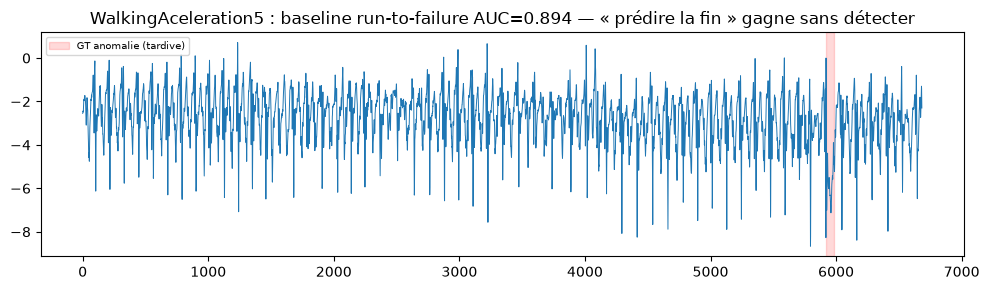

In [7]:
# Piège 4 : Run-to-failure — « prédire la fin » sans rien détecter
def run_to_failure_scores(labels):
    """Baseline dégénérée : score croissant vers la fin (prédit que la fin est anormale)."""
    return np.linspace(0, 1, len(labels))

# WalkingAceleration5 : l'anomalie est à ~89% de la série (presque à la fin)
x4, lab4, ds4 = load_series('162_UCR_Anomaly_WalkingAceleration5_2700_5920_5979.txt')
rtf = run_to_failure_scores(lab4)
print(f'{ds4} : anomalie à {100*lab4.argmax()/len(lab4):.0f}% de la série (tardive)')
print(f'  baseline run-to-failure : AUC = {auc(lab4, rtf):.3f}   ← gagne SANS rien détecter')
print(f'  Vrai détecteur SPC sur la même série : AUC = {auc(lab4, spc_scores(x4)):.3f}')
print('\n→ Si un benchmark place TOUJOURS l\'anomalie à la fin, cette baseline le "résout" : '
      'le score ne mesure aucun pouvoir de détection. C\'est le biais run-to-failure.')

plt.figure(figsize=(10, 3))
plt.plot(x4, lw=0.7)
plt.axvspan(np.argmax(lab4), len(lab4) - lab4[::-1].argmax(), color='red', alpha=0.15, label='GT anomalie (tardive)')
plt.title(f'{ds4} : baseline run-to-failure AUC={auc(lab4, rtf):.3f} — « prédire la fin » gagne sans détecter')
plt.legend(loc='upper left', fontsize=7)
plt.tight_layout()
plt.show()

### Comment ce biais gonfle les scores

La baseline run-to-failure n'apprend rien : elle assigne simplement un score croissant vers la fin. Sur `WalkingAceleration5`, dont l'anomalie est à 89 % de la série, elle obtient un AUC ≈ 0.89 — presque autant que le SPC réellement efficace (0.96). Un benchmark qui place **toujours** l'anomalie en fin de série récompense donc un détecteur qui ne détecte rien. La parade, côté communauté : **varier les positions d'anomalie** dans le benchmark (ce que fait l'UCR Archive) et **comparer systématiquement à une baseline dégénérée** — si la méthode ne dépasse pas nettement cette baseline, le score n'a aucune valeur de progression.


## 4. Un benchmark honnête : l'UCR Archive, où les méthodes échouent (enfin)

Si un benchmark est trivial, SPC le résout. Si un benchmark est **honnête**, la baseline simple s'effondre. On teste SPC sur **2sddb40**, une anomalie **collective** (toute une région dévie doucement, sans pic isolé) — précisément le genre que `M + 3σ` ne voit pas.

Le résultat attendu : SPC **échoue** (AUC ≈ hasard), et même l'auto-encodeur ne fait que modérément. C'est **le** signal qu'on mesure quelque chose de réel : sur un problème honnête, ni la méthode simple ni le réseau ne s'en sortent à bon compte.


2sddb40 : anomalie collective (anomalie = 0.4% de la série)
  SPC AUC = 0.172   (≈ hasard si ~0.5)
  AE  AUC = 0.531

→ Sur un benchmark honnête, SPC ne gagne plus : 0.17. C'est le signal que celui-ci n'est pas trivial.
  Les anomalies collectives exigent de modéliser le CONTEXTE (→ ML-11 Matrix Profile).


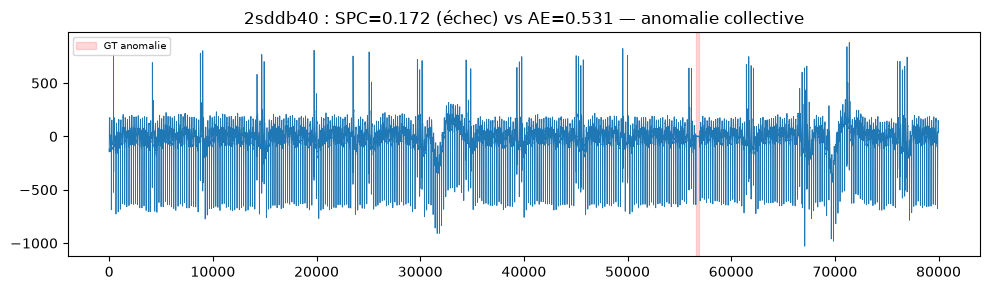

In [8]:
# Benchmark honnête : anomalie collective — SPC s'effondre
x6, lab6, ds6 = load_series('110_UCR_Anomaly_2sddb40_35000_56600_56900.txt')
spc6 = spc_scores(x6)
ae6 = ae_recon_scores(x6)
print(f'{ds6} : anomalie collective (anomalie = {100*lab6.sum()/len(lab6):.1f}% de la série)')
print(f'  SPC AUC = {auc(lab6, spc6):.3f}   (≈ hasard si ~0.5)')
print(f'  AE  AUC = {auc(lab6, ae6):.3f}')
print(f'\n→ Sur un benchmark honnête, SPC ne gagne plus : {auc(lab6, spc6):.2f}. '
      f'C\'est le signal que celui-ci n\'est pas trivial.')
print('  Les anomalies collectives exigent de modéliser le CONTEXTE (→ ML-11 Matrix Profile).')

plt.figure(figsize=(10, 3))
plt.plot(x6, lw=0.6)
plt.axvspan(np.argmax(lab6), len(lab6) - lab6[::-1].argmax(), color='red', alpha=0.15, label='GT anomalie')
plt.title(f'{ds6} : SPC={auc(lab6, spc6):.3f} (échec) vs AE={auc(lab6, ae6):.3f} — anomalie collective')
plt.legend(loc='upper left', fontsize=7)
plt.tight_layout()
plt.show()

### L'auto-encodeur échoue aussi — et c'est le signal

Sur `2sddb40`, SPC retombe à ≈ 0.17 (quasi hasard) et l'auto-encodeur plafonne à ≈ 0.53. Ni l'algorithme de 1924 ni le réseau ne « gagnent » : c'est le comportement attendu d'un benchmark **honnête**. Un score parfait sur un problème difficile serait suspect — il signalerait que le benchmark est encore trivial. Le contraste avec `tiltAPB4`, où la même méthode atteignait ~1.0, rend la leçon tangible : **quand on change la nature de l'anomalie (ponctuelle → collective), la même méthode passe de parfait à quasi-nul.** Le fait que les méthodes simples ET complexes échouent est précisément la preuve qu'on mesure enfin quelque chose de réel — et que le problème (anomalies collectives/contextuelles) mérite l'outil dédié qu'est le Matrix Profile.


### Interprétation : ce qu'un benchmark honnête change

Sur **2sddb40**, SPC retombe à **~0.17** (quasi hasard) et l'auto-encodeur ne dépasse pas ~0.53. Le contraste avec `tiltAPB4` (SPC ≈ 0.998) est le cœur de la leçon : **le même algorithme passe de parfait à quasi-nul suivant le benchmark**. Quand il passe de parfait à nul, c'est que le premier benchmark ne mesurait rien de difficile.

C'est pourquoi Wu & Keogh proposent l'**UCR Time Series Anomaly Archive** : des séries réelles avec des anomalies *variées* (ponctuelles, contextuelles, collectives) et une densité **réaliste** (médiane < 1 %, mesurée plus haut). Sur un tel benchmark, les méthodes simples ne gagnent plus gratuitement.


## 5. Le constat étendu (2024-2025) : l'introspection continue

Le problème ne s'est pas arrêté en 2020. En **2024**, Liu & Paparrizos publient *« The Elephant in the Room: Towards A Reliable Time-Series Anomaly Detection Benchmark »* (NeurIPS 2024, *Datasets & Benchmarks Track*) avec **TSB-AD-M**. En **2025**, Keogh (l'un des auteurs de 2020) signale sur [un fil r/MachineLearning](https://www.reddit.com/r/MachineLearning/comments/1w1wt1s/you_can_beat_sota_time_series_anomaly_detection/) que la **baseline SPC de 1924 bat le SOTA** sur TSB-AD-M et obtient des résultats parfaits sur certaines traces ECG. La communauté s'interroge encore.

> **Le statut de cette dernière source, et pourquoi on s'y arrête.** Le fil Reddit est un **message de forum, pas une publication archivée** : ni relecture par les pairs, ni DOI, ni garantie de permanence — demain le fil peut être supprimé. On le cite parce qu'il est *daté et attribuable*, et parce qu'il montre que l'introspection continue ; mais la thèse de fond qu'il illustre, elle, repose sur l'article archivé de 2020 (arXiv:2009.13807), pas sur le fil. Un notebook qui enseigne à se méfier d'un score sans regarder comment il est mesuré se doit d'appliquer la même exigence à ses propres sources : distinguer ce qui est **établi** de ce qui est **rapporté**.

**La morale transversale :** avant de s'extasier sur un score, regarder **comment il est mesuré** — la trivialité, la densité, l'étiquetage et la chronologie (run-to-failure) peuvent tous gonfler un score sans que le modèle ait rien appris.

**Alternative au deep learning** : le **Matrix Profile** (calcul d'un motif de similarité le long de la série) n'apprend pas, mais modélise le contexte local — il est fait pour les anomalies contextuelles/collectives. C'est l'objet du notebook ****ML-11 (à venir)****.


## Exercice 1 — Quelle anomalie résiste à SPC, et pourquoi ? <a id=\"exercice-1\"></a>

Parmi les séries chargées, une anomalie **contextuelle** (décalage de niveau, comme `InternalBleeding16`) « résiste » à SPC alors qu'une ponctuelle (comme `tiltAPB4`) est résolue en une ligne.

**À faire :** charger `InternalBleeding16`, calculer le score SPC, et expliquer **pourquoi** `M + 3σ` ne voit pas un décalage lent de niveau (alors que l'auto-encodeur, lui, le voit). Formuler la réponse en termes de « anomalie ponctuelle vs contextuelle » — c'est la distinction que le Matrix Profile (ML-11) traite.

# TODO étudiant


In [9]:
# Exercice 1 : pourquoi SPC rate l'anomalie contextuelle ?
# TODO étudiant : charger InternalBleeding16, calculer spc_scores, imprimer l'AUC
#   puis expliquer en commentaire pourquoi M + 3σ (base sur mean/std globaux)
#   ne voit pas un décalage de niveau lent.
# Indice : comparer le score SPC dans la fenêtre d'anomalie vs hors fenêtre.
#   Le décalage est-il un grand écart absolu, ou un petit écart PERSISTANT ?
pass

## Exercice 2 — Mesurer la densité d'un benchmark <a id=\"exercice-2\"></a>

Un benchmark ne devrait pas être plus d'~5 % anormal. **À faire :** écrire une fonction qui mesure la densité d'anomalies (fraction de points étiquetés) d'un benchmark quelconque, et l'appliquer pour comparer une série UCR réaliste à un benchmark « gonflé » (50 %+ anormal).

# TODO étudiant


In [10]:
# Exercice 2 : mesurer la densité d'anomalies d'un benchmark
# TODO étudiant : écrire def densite(labels) -> fraction de 1 ;
#   comparer la densité réelle d'une série UCR (donnée) à un benchmark artificiel
#   dont 50% des points sont étiquetés anormaux ; conclure sur la plausibilité.
# Indice : densite = labels.mean() ;  un taux > 0.5 rend la détection quasi triviale.
pass

## Exercice 3 — La baseline « prédire la fin » <a id=\"exercice-3\"></a>

La baseline **run-to-failure** gagne sans rien détecter. **À faire :** l'implémenter (score croissant vers la fin) et **montrer** qu'elle obtient un AUC élevé sur une série dont l'anomalie est strictement à la fin — puis expliquer pourquoi ce score est trompeur.

# TODO étudiant


In [11]:
# Exercice 3 : implémenter et tester la baseline run-to-failure
# TODO étudiant : def run_to_failure(n) -> np.linspace(0,1,n) ;
#   construire une série factice avec anomalie à la toute fin ;
#   calculer l'AUC de la baseline ; montrer qu'il est proche de 1 ;
#   conclure que ce score ne mesure AUCUN pouvoir de détection.
pass

## Résumé

| Concept | Résultat observé (données réelles UCR) |
|---|---|
| SPC (`M+3σ`, 1924) | 3 lignes de NumPy ; AUC = **~1.0** sur anomalie ponctuelle (`tiltAPB4`) |
| Auto-encodeur (`MLPRegressor`) | AUC ≈ 0.73 sur la même série → **perd face à SPC** sur un benchmark trivial |
| Piège trivialité | Une ligne `|x-mean|>3σ` suffit → le benchmark ne teste rien de difficile |
| Piège densité | Série UCR réaliste : médiane < 1 % ; benchmarks défaillants > 50 % |
| Piège étiquetage | Décaler l'étiquette GT fait chuter l'AUC du même détecteur |
| Piège run-to-failure | « Prédire la fin » gagne sans détecter si l'anomalie est tardive |
| Benchmark honnête | `2sddb40` : SPC = 0.17 (échec), AE = 0.53 → rien n'est gratuit |

**En une phrase :** un score élevé sur un benchmark trivial ne prouve rien ; **mesurer honnêtement** (anomalies variées, densité réaliste, étiquettes justes, sans biais temporel) est ce qui distingue un progrès réel d'une illusion.


## Références

- Wu, R. & Keogh, E. J. (2020/2021). *Current Time Series Anomaly Detection Benchmarks are Flawed and are Creating the Illusion of Progress*. arXiv:2009.13807, IEEE TKDE 2021.
- Keogh, E. (2025). Fil [r/MachineLearning](https://www.reddit.com/r/MachineLearning/comments/1w1wt1s/you_can_beat_sota_time_series_anomaly_detection/) : la baseline SPC (1924) bat le SOTA sur TSB-AD-M. **Source non archivée** — message de forum, sans relecture par les pairs : citée pour la traçabilité de l'affirmation 2025, elle ne porte aucun des résultats mesurés dans ce notebook (voir l'encadré en section 5).
- Liu, Q. & Paparrizos, J. (2024). *The Elephant in the Room: Towards A Reliable Time-Series Anomaly Detection Benchmark*. NeurIPS 2024, *Datasets & Benchmarks Track* (TSB-AD-U / TSB-AD-M) — [actes NeurIPS](https://proceedings.neurips.cc/paper_files/paper/2024/hash/c3f3c690b7a99fba16d0efd35cb83b2c-Abstract-Datasets_and_Benchmarks_Track.html) · [page du benchmark](https://thedatumorg.github.io/TSB-AD/).
- UCR Time Series Anomaly Archive : <https://www.cs.ucr.edu/~eamonn/time_series_data_2018/> — les données réelles utilisées ici.
